# Introduction to Object Detection

## Classification vs Detection vs Segmentation

| Task | Output | Example |
|------|--------|----------|
| **Classification** | Single label | "This is a cat" |
| **Object Detection** | Bounding boxes + labels | "Cat at (x1,y1,x2,y2)" |
| **Semantic Segmentation** | Pixel-wise class labels | Every pixel labeled |
| **Instance Segmentation** | Per-object pixel masks | Each cat has its own mask |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

## Bounding Box Representation

Two common formats:

1. **Corner format**: `(x1, y1, x2, y2)` - top-left and bottom-right corners
2. **YOLO format**: `(x_center, y_center, width, height)` - normalized to [0,1]

In [ ]:
def corner_to_yolo(box, img_width, img_height):
    """Convert (x1, y1, x2, y2) to normalized (cx, cy, w, h)."""
    x1, y1, x2, y2 = box
    cx = ((x1 + x2) / 2) / img_width
    cy = ((y1 + y2) / 2) / img_height
    w = (x2 - x1) / img_width
    h = (y2 - y1) / img_height
    return cx, cy, w, h

def yolo_to_corner(box, img_width, img_height):
    """Convert normalized (cx, cy, w, h) to (x1, y1, x2, y2)."""
    cx, cy, w, h = box
    x1 = (cx - w/2) * img_width
    y1 = (cy - h/2) * img_height
    x2 = (cx + w/2) * img_width
    y2 = (cy + h/2) * img_height
    return x1, y1, x2, y2

# Example
corner_box = (100, 50, 300, 200)  # pixels
yolo_box = corner_to_yolo(corner_box, 640, 480)
print(f"Corner format: {corner_box}")
print(f"YOLO format: {[f'{v:.3f}' for v in yolo_box]}")

Corner format: (100, 50, 300, 200)
YOLO format: ['0.312', '0.260', '0.312', '0.312']


## IoU: Intersection over Union

IoU measures how much two boxes overlap:

$$\text{IoU} = \frac{\text{Area of Intersection}}{\text{Area of Union}}$$

- IoU = 1: Perfect overlap
- IoU = 0: No overlap
- IoU > 0.5: Typically considered a "match"

In [ ]:
def calculate_iou(box1, box2):
    # The intersection rectangle is defined by taking the inner corners.
    x1 = max(box1[0], box2[0])   # left edge of intersection
    y1 = max(box1[1], box2[1])   # top edge of intersection
    x2 = min(box1[2], box2[2])   # right edge of intersection
    y2 = min(box1[3], box2[3])   # bottom edge of intersection

    # Clamp to 0: if boxes don't overlap, one dimension will be negative.
    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    # Union = sum of both areas minus the double-counted intersection.
    union = area1 + area2 - intersection

    return intersection / union if union > 0 else 0

box_a = (100, 100, 200, 200)
box_b = (150, 150, 250, 250)
print(f"IoU: {calculate_iou(box_a, box_b):.3f}")

IoU: 0.143


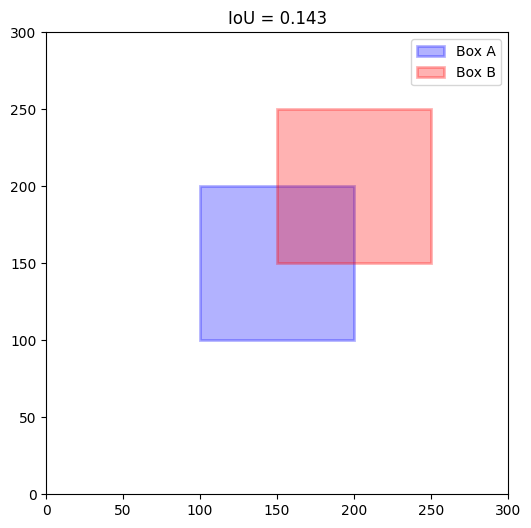

In [ ]:
# Visualize IoU
fig, ax = plt.subplots(figsize=(6, 6))

rect_a = patches.Rectangle((100, 100), 100, 100, linewidth=2, 
                            edgecolor='blue', facecolor='blue', alpha=0.3, label='Box A')
rect_b = patches.Rectangle((150, 150), 100, 100, linewidth=2,
                            edgecolor='red', facecolor='red', alpha=0.3, label='Box B')

ax.add_patch(rect_a)
ax.add_patch(rect_b)
ax.set_xlim(0, 300)
ax.set_ylim(0, 300)
ax.set_aspect('equal')
ax.legend()
ax.set_title(f'IoU = {calculate_iou(box_a, box_b):.3f}')
plt.show()

## Non-Maximum Suppression (NMS)

Object detectors often produce multiple overlapping boxes for the same object.

**NMS** removes redundant detections:
1. Sort boxes by confidence score
2. Keep the highest-scoring box
3. Remove boxes with IoU > threshold with the kept box
4. Repeat for remaining boxes

In [ ]:
def nms(boxes, scores, iou_threshold=0.5):
    # Sort by score descending — we always want to keep the most confident box.
    # Sorting by score (not area) ensures the best detection wins.
    indices = np.argsort(scores)[::-1]
    keep = []

    while len(indices) > 0:
        current = indices[0]   # highest-scoring remaining box
        keep.append(current)

        if len(indices) == 1:
            break

        # Suppress all remaining boxes that overlap too much with `current`.
        # This removes redundant detections of the same underlying object.
        remaining = []
        for i in indices[1:]:
            if calculate_iou(boxes[current], boxes[i]) < iou_threshold:
                remaining.append(i)   # keep: low overlap → different object
            # else: discard — overlaps too much with a higher-scoring box
        indices = remaining

    return keep

boxes = [
    (100, 100, 200, 200),
    (110, 105, 210, 205),  # overlaps with first (should be suppressed)
    (105, 102, 205, 202),  # overlaps with first (should be suppressed)
    (300, 300, 400, 400),  # separate object (should be kept)
]
scores = [0.9, 0.75, 0.8, 0.85]

kept_indices = nms(boxes, scores, iou_threshold=0.5)
print(f"Kept boxes: {kept_indices}")
print(f"Before NMS: {len(boxes)} boxes → After NMS: {len(kept_indices)} boxes")

Kept boxes: [np.int64(0), np.int64(3)]
Before NMS: 4 boxes → After NMS: 2 boxes


## Detection Metrics

### Precision and Recall

- **True Positive (TP)**: Correct detection (IoU > threshold)
- **False Positive (FP)**: Detection that doesn't match any ground-truth box ("hallucination")
- **False Negative (FN)**: Ground-truth object that was not detected ("missed")

$$\text{Precision} = \frac{TP}{TP + FP}$$

> *Intuition: "Of all boxes I predicted, how many were actually correct?"* — measures how trustworthy the model's detections are.

$$\text{Recall} = \frac{TP}{TP + FN}$$

> *Intuition: "Of all real objects in the image, how many did I find?"* — measures how thorough the model is.

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

**mAP (mean Average Precision)**: averaged over all classes and IoU thresholds. The primary metric for comparing detectors.

## Object Detection Architectures

### Two-Stage Detectors
1. Propose regions (RPN)
2. Classify and refine regions

Examples: **R-CNN**, **Fast R-CNN**, **Faster R-CNN**

### One-Stage Detectors
Predict boxes and classes in a single pass.

Examples: **YOLO**, **SSD**, **RetinaNet**

| Approach | Speed | Accuracy |
|----------|-------|----------|
| Two-stage | Slower | Higher |
| One-stage | Faster | Slightly lower |

## YOLO Overview

**You Only Look Once**: Real-time object detection.

1. Divide image into grid (e.g., 13×13)
2. Each cell predicts multiple bounding boxes
3. Each prediction: (x, y, w, h, confidence, class scores)

```
Image → [CNN Backbone] → Feature Map → [Detection Head] → Boxes + Classes
```

## Summary

| Concept | Description |
|---------|-------------|
| **Bounding Box** | Rectangle around object |
| **IoU** | Overlap measure (0-1) |
| **NMS** | Remove duplicate detections |
| **mAP** | Standard detection metric |
| **YOLO** | Real-time one-stage detector |